# Building and running a `MutableAnsatzExperiment`

This notebook demonstrates a complete QAdaptive workflow for constructing and running a
`MutableAnsatzExperiment`.

The underlying variational problem is deliberately simple. The focus is not on obtaining a
particular physics result, but on showing how the different QAdaptive components fit together:
how to define an adaptive ansatz, configure the inner-loop optimizer and recorder, construct
outer-loop plan builders, combine plans into a schedule, run the adaptive optimization, and
save the resulting experiment history.

In particular, this example will show how to:

- create an `AdaptiveAnsatz` from a standard Qiskit circuit;
- configure an `InnerLoopRecorder`, optimizer, and `InnerLoopTrainer`;
- assemble these objects into a `MutableAnsatzExperiment`;
- define reusable growth and pruning plan builders;
- provide custom insertion and qubit-selection rules;
- combine multiple structural actions into a single outer-loop proposal;
- build a complete plan schedule;
- configure and run `run_outer_loop`;
- inspect and save the resulting experiment history.

## Imports

We only import the components needed to define the variational problem, construct the
QAdaptive experiment, configure the adaptation schedule, and inspect or save the result.

In [1]:
import random
from functools import partial
from pathlib import Path

import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp, Statevector

from qadaptive import (
    AdaptiveAnsatz,
    InnerLoopRecorder,
    InnerLoopTrainer,
    MutableAnsatzExperiment,
)

from qadaptive.outer import (
    between_2qg_indices_policy,
    build_least_used_pair_growth_plan,
    build_prune_sweep_plan,
    build_single_qubit_block_plan,
    build_targeted_prune_plan,
    build_uniform_growth_plan,
    combine_plan_builders,
    make_select_random_gates,
)

from qadaptive.training import (
    SPSA,
    TerminationChecker,
)

from qadaptive.utils import custom_pass_manager

## 1. Define a simple variational problem

QAdaptive is agnostic to the variational problem being solved. It only requires a loss
function that can evaluate the current parameterized ansatz.

For this example, we use a small three-qubit transverse-field Ising Hamiltonian. The
particular Hamiltonian and the quality of the final VQE solution are not important here;
the purpose of the problem is simply to provide a concrete objective while demonstrating
the adaptive workflow.

We also compute the exact ground-state energy. This will only be used later as an optional
reference value for the inner-loop termination criterion.

In [2]:
num_qubits = 3

H = SparsePauliOp.from_list([
    ("ZZI", -1.0),
    ("IZZ", -1.0),
    ("XII", -0.5),
    ("IXI", -0.5),
    ("IIX", -0.5),
])

reference_energy = np.linalg.eigvalsh(H.to_matrix())[0]

print(f"Reference ground-state energy: {reference_energy:.6f}")

Reference ground-state energy: -2.403212


### Statevector loss function

For clarity, this example evaluates the energy exactly with a statevector simulator rather
than introducing shot noise or backend-specific details.

The loss function follows the interface expected by `InnerLoopTrainer`: it receives a
parameter vector and the current ansatz through the `ansatz` keyword argument.

In [3]:
def energy_function(
    params: list[float] | np.ndarray,
    ansatz: QuantumCircuit,
) -> float:
    """Calculate the energy expectation value of the Hamiltonian for a given set of parameters and an ansatz."""
    parameter_map = dict(zip(ansatz.parameters, params))
    bound_circuit = ansatz.assign_parameters(parameter_map)

    state = Statevector.from_instruction(bound_circuit)
    energy = state.expectation_value(H).real

    return float(energy)

## 2. Create the adaptive ansatz

A QAdaptive experiment starts from an ordinary parameterized Qiskit circuit. The initial
circuit can be as simple or as structured as required by the problem.

Here we start with two local rotations on each qubit and no entangling gates. The outer
loop will be responsible for modifying this architecture later.

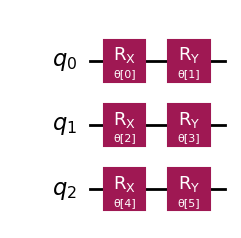

In [4]:
theta = ParameterVector("θ", 2 * num_qubits)

initial_circuit = QuantumCircuit(num_qubits)

for q in range(num_qubits):
    initial_circuit.rx(theta[2 * q], q)
    initial_circuit.ry(theta[2 * q + 1], q)

initial_circuit.draw("mpl")

### Wrap the circuit in an `AdaptiveAnsatz`

`AdaptiveAnsatz` is QAdaptive's mutable representation of the parameterized circuit. It
tracks the current circuit structure and manages parameters as gates and blocks are added
or removed.

`from_generic_circuit` is a convenient constructor for starting from an arbitrary Qiskit
circuit. Among other things, it normalizes the parameter names to the convention used
internally by QAdaptive.

An `AdaptiveAnsatz` also owns two pools that determine which structural elements are
available during adaptation:

- the **operator pool**, containing individual gates that may be inserted;
- the **block pool**, containing reusable multi-gate `PoolBlock` objects.

Both pools can be supplied when the `AdaptiveAnsatz` is created. If they are omitted,
QAdaptive uses its built-in default operator and block pools. Plan builders can then refer
to entries in these pools by name when constructing structural proposals.

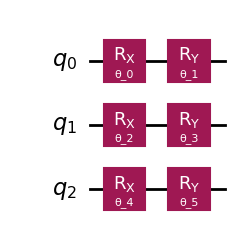

In [5]:
adaptive_ansatz = AdaptiveAnsatz.from_generic_circuit(initial_circuit)

adaptive_ansatz.current_ansatz.draw("mpl")

# Custom pools can alternatively be supplied:
# adaptive_ansatz = AdaptiveAnsatz.from_generic_circuit(
#     initial_circuit,
#     operator_pool=custom_operator_pool,
#     block_pool=custom_block_pool,
# )

## 3. Configure the inner-loop training

QAdaptive separates **parameter optimization** from **structural adaptation**.

During an inner loop, the circuit architecture is fixed and only its trainable parameters
are optimized. The outer loop, introduced later, modifies the circuit structure between
these training runs.

The inner loop is assembled from three components:

1. an `InnerLoopRecorder`, which stores the optimization history;
2. a `StepwiseOptimizer`, which proposes parameter updates;
3. an `InnerLoopTrainer`, which coordinates repeated optimization steps for a fixed ansatz.

Keeping these responsibilities separate makes it possible to change the optimizer or
recording configuration without changing the structural adaptation logic.

### Record the inner-loop history

`InnerLoopRecorder` persists information from every training run performed during the
experiment. Here we record both the objective value at the initial point and the SPSA
gradient estimates so that they are available for later analysis and visualization.

In [6]:
recorder = InnerLoopRecorder(
    record_initial_value=True,
    record_gradients=True,
)

### Define an optional termination criterion

Each inner-loop run has a maximum number of training iterations, but it may also terminate
early when a user-defined criterion is satisfied.

For this example, training stops if the objective approaches the exact reference energy or
if the recent objective history has reached a sufficiently flat plateau. These settings are
only illustrative and are not intended as optimized VQE hyperparameters.

In [7]:
termination_checker = TerminationChecker(
    mode="min",
    target_value=float(reference_energy),
    target_tol=1e-2,
    plateau_window=20,
    plateau_slope_tol=1e-3,
    plateau_improvement_tol=5e-3,
    verbose=False,
)

### Configure the optimizer

We use QAdaptive's stepwise `SPSA` implementation for parameter optimization.

The learning-rate and perturbation sequences are defined using the usual SPSA power-law
schedules. The particular values below are simply reasonable settings for this small
example; optimizer tuning is not the focus of this notebook.

In [8]:
optimizer = SPSA(
    resamplings=1,
)

optimizer.set_power_series_hyperparameters(
    a=0.4,
    alpha=0.602,
    stability_constant=0.0,
    c=0.1,
    gamma=0.101,
)

### Create the inner-loop trainer

`InnerLoopTrainer` combines the optimizer, recorder, and optional termination criterion.
It is responsible for training a fixed circuit for one inner-loop run.

The same trainer will be reused as the outer loop changes the ansatz architecture.

In [9]:
trainer = InnerLoopTrainer(
    optimizer=optimizer,
    recorder=recorder,
    termination_checker=termination_checker,
)

## 4. Create the `MutableAnsatzExperiment`

We now have the two main ingredients of an adaptive experiment:

- an `AdaptiveAnsatz`, which owns the mutable circuit architecture;
- an `InnerLoopTrainer`, which optimizes the parameters of the current architecture.

`MutableAnsatzExperiment` brings these components together and manages the alternating
sequence of parameter training and structural modification that forms the adaptive outer
loop.

At this point the experiment is fully initialized.

In [10]:
experiment = MutableAnsatzExperiment(
    adaptive_ansatz=adaptive_ansatz,
    trainer=trainer,
)

## 5. Define the structural adaptation strategy

The inner loop determines how the parameters of a fixed circuit are trained. The outer loop
determines how the circuit architecture itself is allowed to change.

In QAdaptive, structural changes are described by **plan builders**. A plan builder receives
the current `MutableAnsatzExperiment` and returns an `OuterStepPlan` containing one or more
structural actions, such as inserting parameterized blocks, pruning entangling gates, or
simplifying the circuit.

The builders provided by QAdaptive are convenience functions rather than a closed set of
adaptation algorithms. Users can configure them, combine them, or define entirely new plan
builders in their own code.

In this example we construct a small adaptation strategy containing:

- entangling growth;
- local single-qubit growth;
- targeted pruning;
- circuit simplification.

Along the way, we will also define custom rules for where new blocks should be inserted and
which qubits should receive additional trainable parameters.

### Configure circuit simplification

Some outer-loop plans can request circuit simplification after modifying the ansatz.

Here we construct a pass manager used by those simplification actions. The exact
transpilation choices are application-dependent; this configuration is simply used
throughout the example so that structurally redundant operations can be removed
consistently.

In [11]:
pass_manager = custom_pass_manager(
    remove_initial_rz=True,
)

### Define a custom insertion policy

Block-insertion builders can accept an insertion policy that determines where a new block
is placed in the circuit.

An insertion policy is a callable with the signature

`(experiment, target_qubits, insertion_number) -> int`

where the returned integer is a circuit-data index.

For this example, we define a simple policy that always inserts the requested block at the
beginning of the circuit.

In [12]:
def insert_at_beginning(
    experiment: MutableAnsatzExperiment,
    target_qubits: list[int],
    insertion_number: int,
) -> int:
    """Return the first circuit-data index for every requested insertion."""
    return 0

QAdaptive also provides reusable insertion policies. Later we will use
`between_2qg_indices_policy`, which attempts to place a block between relevant two-qubit
gates rather than at a fixed circuit position.

### Define a custom qubit-selection rule

The location of a structural modification can also depend on the current state of the
ansatz.

For the single-qubit growth step below, we would like to add trainable rotations only to
the qubit that currently has the fewest trainable parameters. Rather than encoding this
choice inside the plan builder, we define it as a separate callable.

The selector counts the distinct trainable parameters that act on each qubit and randomly
breaks ties between equally parameterized qubits.

In [13]:
def select_least_parameterized_qubit(
    experiment: MutableAnsatzExperiment,
) -> list[int]:
    """Return the least-parameterized qubit, breaking ties randomly."""
    circuit = experiment.ansatz

    params_by_qubit: dict[int, set] = {
        q: set() for q in range(circuit.num_qubits)
    }

    for instruction in circuit.data:
        instruction_params = set()

        for parameter_expression in instruction.operation.params:
            instruction_params.update(
                getattr(parameter_expression, "parameters", set())
            )

        for qubit in instruction.qubits:
            qubit_index = circuit.find_bit(qubit).index
            params_by_qubit[qubit_index].update(instruction_params)

    parameter_counts = {
        qubit: len(parameters)
        for qubit, parameters in params_by_qubit.items()
    }

    min_count = min(parameter_counts.values())
    candidates = [
        qubit
        for qubit, count in parameter_counts.items()
        if count == min_count
    ]

    return [random.choice(candidates)]

### Configure reusable plan builders

The built-in plan builders expose several options controlling what structural change is
proposed and how it is performed.

Rather than repeating those options every time a plan is requested, we use
`functools.partial` to create configured builders. The resulting objects still accept the
current experiment when called by the outer loop, but the remaining configuration is fixed.

This makes a plan schedule read more like a description of the adaptation strategy than a
collection of low-level function calls.

In [14]:
initial_entangling_growth = partial(
    build_uniform_growth_plan,
    block_name="single_cx_block",
    insert_index_policy=insert_at_beginning,
    force_accept=False,
    add_simplify=False,
)

`initial_entangling_growth` proposes one entangling block for every qubit pair.

Here the blocks are inserted at the beginning of the circuit using the custom policy defined
above. `force_accept=False` means that the resulting structural proposal is still evaluated
by the outer-loop acceptance logic rather than being accepted unconditionally.

In [15]:
single_pair_entangler = partial(
    build_least_used_pair_growth_plan,
    block_name="single_cx_block",
    max_insertions=1,
    insert_index_policy=insert_at_beginning,
    force_accept=False,
    add_simplify=False,
)

For subsequent growth steps we use a more conservative builder.

`build_least_used_pair_growth_plan` prioritizes qubit pairs that currently contain the
least entangling structure. Setting `max_insertions=1` limits each proposal to a single
new entangling block.

In [16]:
local_rotation_builder = partial(
    build_single_qubit_block_plan,
    block_name="rz_rx_rz",
    qubit_selection=select_least_parameterized_qubit,
    insert_index_policy=between_2qg_indices_policy,
    num_insertions=1,
    force_accept=False,
    add_simplify=False,
)

The local-growth builder demonstrates two different kinds of programmable targeting.

`qubit_selection` determines **which qubit** receives a new rotation block. Here this is the
custom least-parameterized-qubit rule defined above.

`insert_index_policy` determines **where in the circuit** that block is inserted. We use
QAdaptive's `between_2qg_indices_policy`, which searches for positions between relevant
two-qubit gates.

The two decisions are therefore independent: one rule selects the target qubit, while
another selects the insertion position.

### Combine structural changes into one proposal

An `OuterStepPlan` may contain more than one structural action.

`combine_plan_builders` creates a new builder by concatenating the plans returned by several
existing builders. The combined structural modification is then treated as one outer-loop
proposal and evaluated together.

Here we simultaneously propose one new entangling block and one new local rotation block.

In [17]:
growth_builder = combine_plan_builders(
    single_pair_entangler,
    local_rotation_builder,
)

This composition mechanism is useful when an architectural update should be evaluated as a
unit. It differs from placing the two builders consecutively in the schedule, where each
plan would constitute a separate outer-loop proposal.

### Configure pruning plans

Growth is only one possible form of adaptation. QAdaptive can also propose removing existing
two-qubit structure.

First, we define a targeted pruning builder. The targeting function chooses candidate gates,
while `max_num_2q_gates` controls how many of those candidates may actually be included in
the proposal.

In [18]:
targeted_prune_builder = partial(
    build_targeted_prune_plan,
    targeting_function=make_select_random_gates(num_gates=2),
    max_num_2q_gates=1,
    add_simplify=True,
    simplify_kwargs={
        "repetitions": 2,
        "pass_manager": pass_manager,
    },
)

For the final stage of the schedule, we use a pruning sweep that attempts pruning across
the currently available two-qubit gates.

After the sweep, the same simplification configuration is applied.

In [19]:
prune_sweep_builder = partial(
    build_prune_sweep_plan,
    add_simplify=True,
    simplify_kwargs={
        "repetitions": 2,
        "pass_manager": pass_manager,
    },
)

## 6. Build the outer-loop plan schedule

A plan schedule specifies which structural proposal should be attempted at each outer-loop
iteration.

For this example we use three stages:

1. an initial uniform entangling-growth proposal;
2. several cycles alternating combined growth and targeted pruning;
3. a final pruning sweep.

The schedule contains **plan builders**, not already-built plans. This is important because
each builder is evaluated against the experiment state that exists when its outer-loop
iteration is reached.

In [20]:
num_cycles = 3

schedule = [initial_entangling_growth]

for _ in range(num_cycles):
    schedule.extend([
        growth_builder,
        targeted_prune_builder,
    ])

schedule.append(prune_sweep_builder)

print(f"Number of outer-loop plans: {len(schedule)}")

Number of outer-loop plans: 8


### Optional: configure logging

QAdaptive uses Python's standard `logging` module throughout the package.

For longer experiments it can be useful to route messages from different QAdaptive
subsystems to separate files. For example, outer-loop events, inner-loop training, and
core circuit modifications can each be recorded independently while also retaining a
combined experiment log.

The configuration below is entirely standard Python logging and can be adapted to the
needs of a particular experiment.

In [21]:
import logging
from pathlib import Path


class NamespaceFilter(logging.Filter):
    """Allow log records originating from a given logger namespace."""

    def __init__(self, namespace: str) -> None:
        super().__init__()
        self.namespace = namespace

    def filter(self, record: logging.LogRecord) -> bool:
        """Return whether the log record belongs to the configured namespace."""
        return record.name.startswith(self.namespace)
    
log_dir = Path("logs")
log_dir.mkdir(exist_ok=True)

formatter = logging.Formatter(
    "%(asctime)s | %(name)s | %(levelname)s | %(message)s"
)

root_logger = logging.getLogger()
root_logger.setLevel(logging.DEBUG)
root_logger.handlers.clear()

log_config = {
    "outer.log": ("qadaptive.outer", logging.DEBUG),
    "training.log": ("qadaptive.training", logging.DEBUG),
    "core.log": ("qadaptive.core", logging.INFO),
}

for filename, (namespace, level) in log_config.items():
    handler = logging.FileHandler(log_dir / filename, mode="w")
    handler.setLevel(level)
    handler.setFormatter(formatter)
    handler.addFilter(NamespaceFilter(namespace))
    root_logger.addHandler(handler)

# Combined QAdaptive log
full_handler = logging.FileHandler(log_dir / "qadaptive.log", mode="w")
full_handler.setLevel(logging.INFO)
full_handler.setFormatter(formatter)
root_logger.addHandler(full_handler)

## 7. Run the adaptive outer loop

The experiment is now fully configured:

- the variational problem defines the objective;
- the `AdaptiveAnsatz` stores the mutable circuit;
- the `InnerLoopTrainer` handles parameter optimization;
- the plan schedule defines how the architecture may evolve.

`run_outer_loop` executes these components together. At each outer iteration, QAdaptive
builds the next plan using the **current** experiment state, applies the proposed structural
modification, retrains the resulting ansatz, and decides whether the proposal should be
retained.

Several options control how training state is propagated between successive architectures.
We configure the most important ones explicitly below.

### Training schedule

`train_before_first_plan=True` performs one inner-loop optimization on the initial ansatz
before any structural modifications are attempted. This establishes a trained baseline
against which the first structural proposal can be compared.

`train_after_plan=True` retrains each modified ansatz before the outer-loop acceptance
decision is made.

`train_iterations` can be either a single integer, used for every training run, or a list
specifying different training budgets throughout the schedule. For this example we use a
constant budget because optimization performance is not the focus of the notebook.

Finally, `trainer_iteration_reset=None` preserves the optimizer's iteration counter across
successive training runs. For schedule-dependent optimizers such as SPSA, this means that
the learning-rate and perturbation schedules continue rather than restarting after every
structural modification.

### Carry trained parameters between architectures

Structural adaptation changes the dimensionality of the parameter vector. QAdaptive's
parameter memory provides a way to transfer trained values between successive architectures.

With

- `update_parameter_memory=True`, the parameter values obtained after training are stored;
- `reuse_parameter_memory=True`, parameters that survive a structural modification are
  initialized from their previously trained values;
- `default_value_for_new_params=0.0`, newly introduced parameters are initialized at zero.

For the rotation and identity-initialized blocks used in this example, zero is a natural
starting value for newly introduced parameters.

`record_parameter_memory=True` additionally stores these parameter-memory states in the
experiment history for later inspection and persistence.

For the very first training run we leave `initial_point=None`, so QAdaptive generates the
initial parameter vector automatically.

A custom `initial_point_generator` can also be supplied when more specialized initialization
logic is required. We do not use one here; when no generator is provided, parameter-memory
reuse controls the initialization of subsequent architectures.

### Decide whether structural proposals are retained

Plans configured with outer acceptance are not automatically retained. After the modified
ansatz has been retrained, its objective is compared with the previously accepted
architecture.

`accept_tol` controls the deterministic acceptance threshold. With `accept_tol=0.0`, a
proposal is deterministically accepted when its objective is no worse than the current
accepted objective.

We also enable optional Metropolis-like acceptance with `metropolis_temperature`. This gives
proposals that fail the deterministic threshold a nonzero probability of being retained,
allowing the architecture search to occasionally move through temporarily worse solutions.

No explicit complexity penalty is used in this example, although `complexity_penalty` can
be supplied when architectural complexity should contribute directly to the acceptance
score.

In [22]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
metropolis_rng = np.random.default_rng(SEED)

In [23]:
results = experiment.run_outer_loop(
    loss_function=energy_function,
    plan_schedule=schedule,
    outer_iterations=len(schedule),

    # Inner-loop training
    train_iterations=30,
    train_before_first_plan=True,
    train_after_plan=True,
    trainer_iteration_reset=None,

    # Parameter initialization and transfer
    initial_point=None,
    initial_point_generator=None,
    update_parameter_memory=True,
    reuse_parameter_memory=True,
    default_value_for_new_params=0.0,
    record_parameter_memory=True,

    # Outer-loop acceptance
    accept_tol=0.0,
    complexity_penalty=None,
    metropolis_temperature=0.2,
    metropolis_rng=metropolis_rng,

    # Fail loudly in an example notebook
    stop_on_error=True,
)

The returned `results` contain summaries of the executed structural outer steps. The
experiment itself retains the richer history of the run, including inner-loop training,
trial architectures, accepted architectures, parameter memory, and outer-step records.

For most analysis and visualization tasks, we therefore interact with `experiment` and its
recorder rather than only with the return value of `run_outer_loop`.

## 8. Inspect the experiment

`MutableAnsatzExperiment` and its `InnerLoopRecorder` retain the history of the adaptive run.

For a typical workflow, it is useful to inspect:

- a compact experiment summary;
- the outer-loop objective history;
- the inner-loop optimization trace;
- the evolution of the circuit architecture;
- the evolution of circuit complexity.

The plots below are intended as examples of the information recorded by QAdaptive rather
than as a detailed analysis of this particular VQE run.

In [24]:
experiment.print_summary()

QAdaptive experiment summary
Current cost: -2.2989973755
Structural proposals: 8 (accepted: 8, rejected: 0)
Inner runs: 9 (completed: 9)
Recorded inner steps: 257
Current parameters: 9
Two-qubit instructions: 0
Optimizer nfev (completed results): 514


### Outer-loop history

The outer-loop history shows how the retained objective changes across structural proposals.
Rejected proposals are still recorded separately in the experiment history, while the
accepted trajectory represents the architectures that were retained.

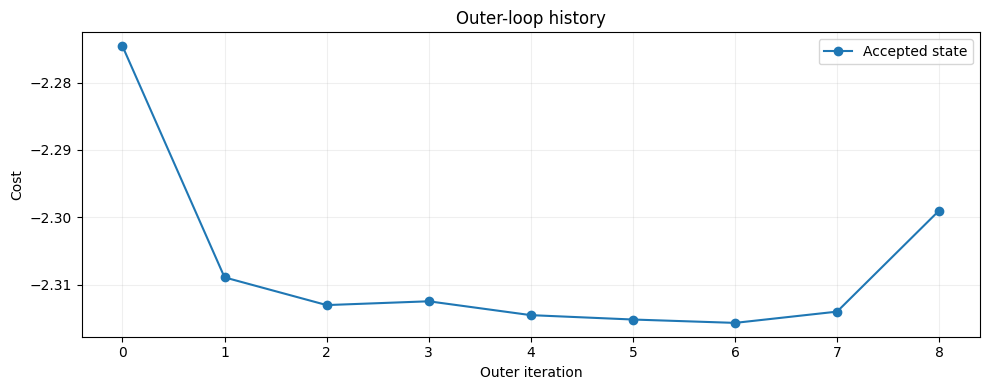

In [25]:
fig, ax = experiment.plot_outer_history()

### Inner-loop training history

The recorder stores the parameter-optimization history from every inner-loop run.
This makes it possible to inspect how training behaved before and after each structural
modification.

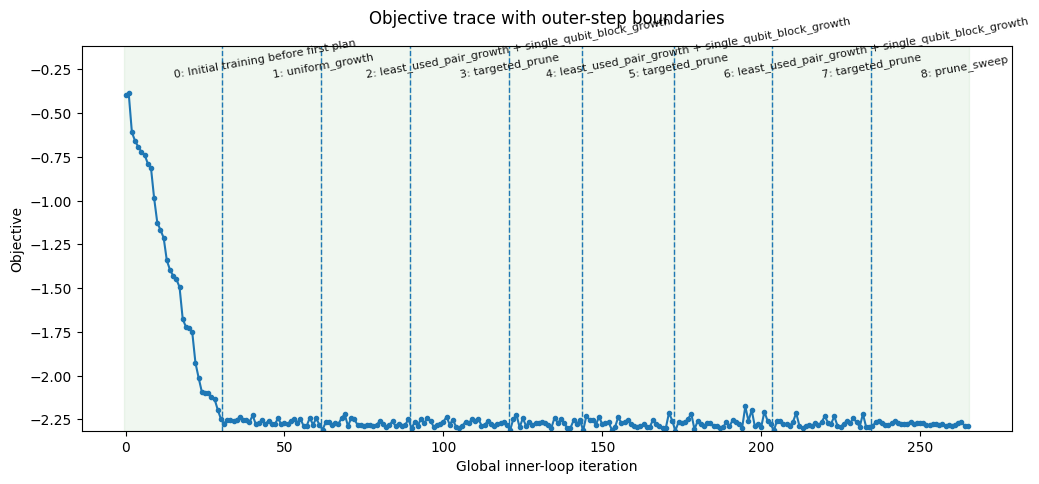

In [26]:
fig, ax = recorder.plot_objective()

### Architecture evolution

QAdaptive stores snapshots of the accepted circuit architectures. These can be visualized
to inspect how the ansatz changed over the course of the adaptive search.

Here we display only the first four accepted architectures.

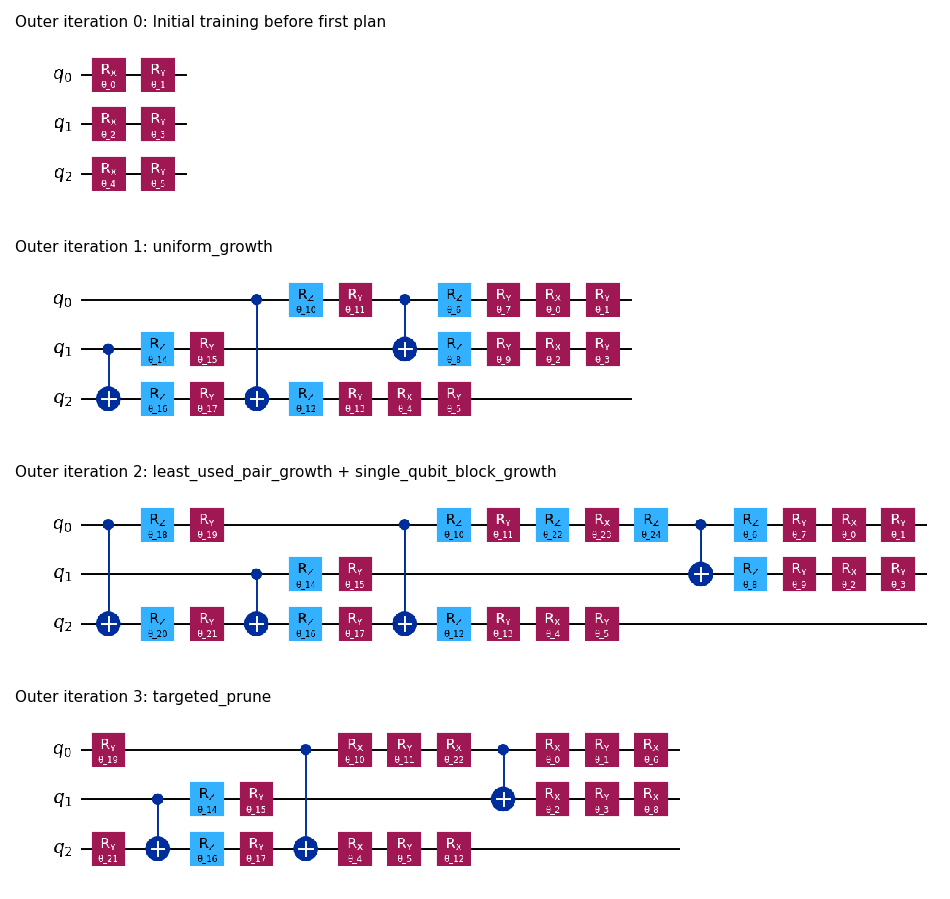

In [27]:
fig, axes = experiment.plot_architecture_evolution(
    indices=[0, 1, 2, 3],
    figsize=(18, 6),
)

### Complexity evolution

Structural adaptation changes both the number of trainable parameters and the amount of
entangling structure in the ansatz. `plot_complexity_evolution` summarizes how these
quantities changed across accepted architectures.

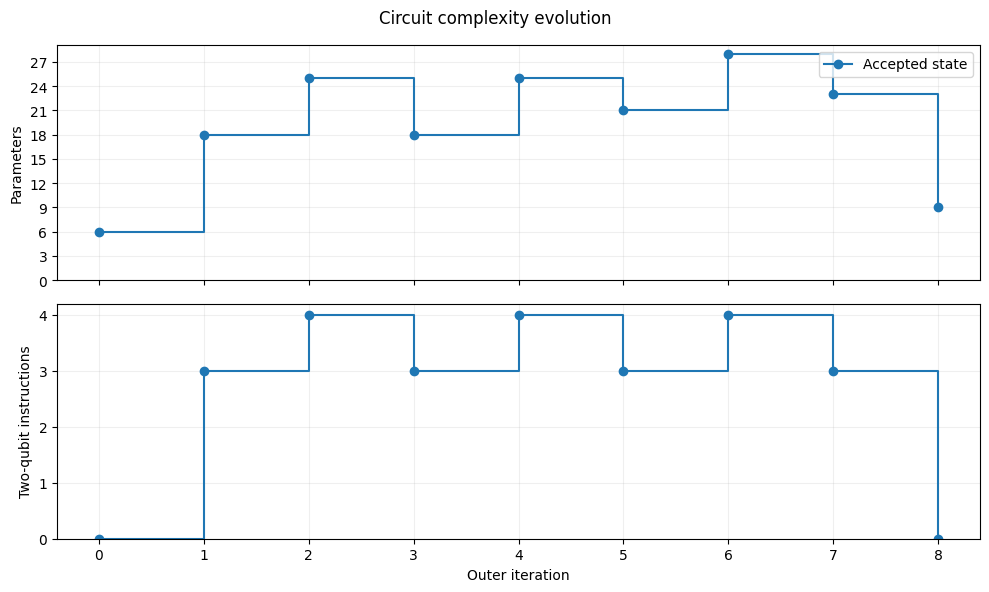

In [28]:
fig, axes = experiment.plot_complexity_evolution()

## 9. Save and reload the experiment history

Adaptive experiments can generate a substantial amount of structural and optimization
history. QAdaptive provides persistence utilities so that a completed run can be saved and
analyzed later without rerunning the optimization.

`save_history` stores the experiment history in a directory and returns the resolved path
that was used.

In [29]:
result_dir = Path("results") / "example_mutable_ansatz_experiment"
result_dir = experiment.save_history(result_dir)

print(f"Saved experiment history to: {result_dir}")

FileExistsError: An archive already exists at results\example_mutable_ansatz_experiment. Choose a new output directory.

The saved history can later be loaded independently of the live experiment object.
The loaded object exposes the same reporting utilities for inspecting the stored run.

QAdaptive experiment summary
Current cost: -2.2973228053
Structural proposals: 8 (accepted: 8, rejected: 0)
Inner runs: 9 (completed: 9)
Recorded inner steps: 263
Current parameters: 9
Two-qubit instructions: 0
Optimizer nfev (completed results): 526


(<Figure size 315x616.333 with 2 Axes>,
 array([<Axes: title={'left': 'Outer iteration 0: Initial training before first plan'}>,
        <Axes: title={'left': 'Outer iteration 8: prune_sweep'}>],
       dtype=object))

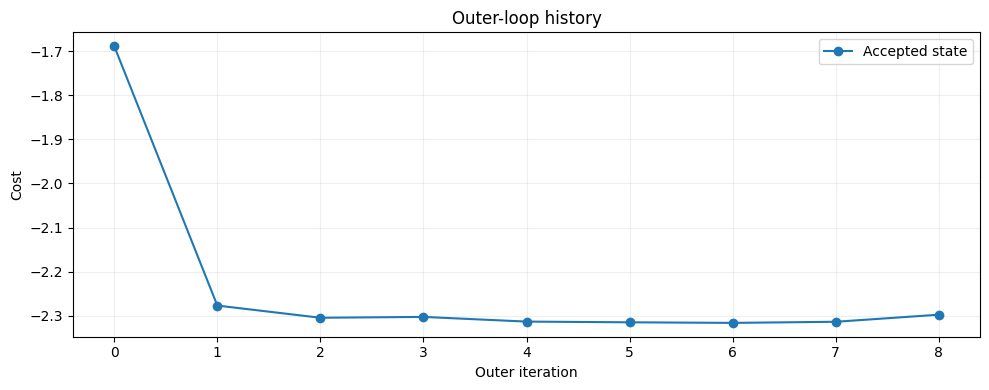

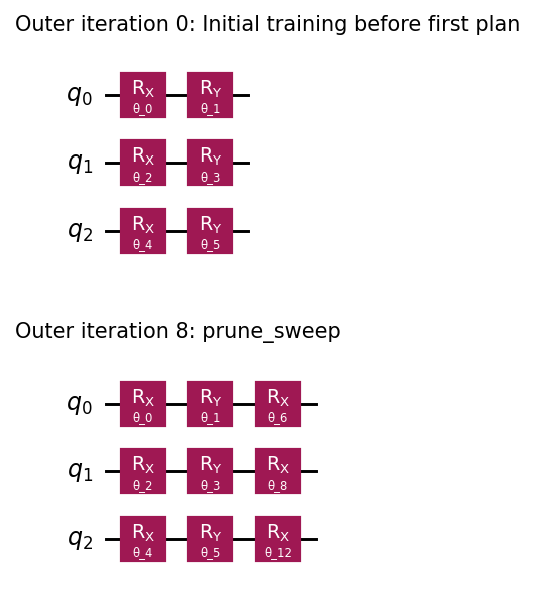

In [ ]:
from qadaptive.persistence.loading import load_experiment_history

loaded = load_experiment_history(result_dir)

loaded.print_summary()
loaded.plot_outer_history()
loaded.plot_architecture_evolution(indices=[0, -1])

## Summary

This example assembled a complete QAdaptive workflow:

1. define a variational objective;
2. create an `AdaptiveAnsatz`;
3. configure the inner-loop trainer;
4. construct a `MutableAnsatzExperiment`;
5. define and combine structural plan builders;
6. assemble an outer-loop schedule;
7. run the adaptive optimization;
8. inspect and persist the resulting history.

The builders and policies used here are only one possible adaptation strategy. They are
ordinary Python callables built on QAdaptive's public interfaces, so users can replace or
extend them to study their own adaptive variational algorithms.